In [ ]:
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2025/blob/main/Y1/notebooks/tinyLLM_example.ipynb)

# Non linear regression

In this second example, we are going to complexify a bit the model, with two layers, one of 4 neurons, the other one of 1 neuron.

Note that it is still a bad idea to use deep learning for this... 

For this example, we're going to try predicting a bit more complex problem: predicting tumour size from time since diagnostic (real data)

In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


Fixing the seeds for replicability

In [2]:
seed = 50

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

Our data comes from a PLOS paper, which study the growth of Lewis lung carcinoma originally derived from a spontaneous tumor in a C57BL/6 mouse.

You can find it here: https://journals.plos.org/ploscompbiol/article%3Fid%3D10.1371/journal.pcbi.1003800m

Here, our X will be time, and Y will be tumour size.


In [3]:
data = pd.read_csv('../data/LLC_sc_CCSB.txt', sep=',', index_col=0)
t = np.expand_dims(data['Time'].values, 1)
size = np.expand_dims(data['Vol'].values, 1)

Text(0, 0.5, 'Tumour size')

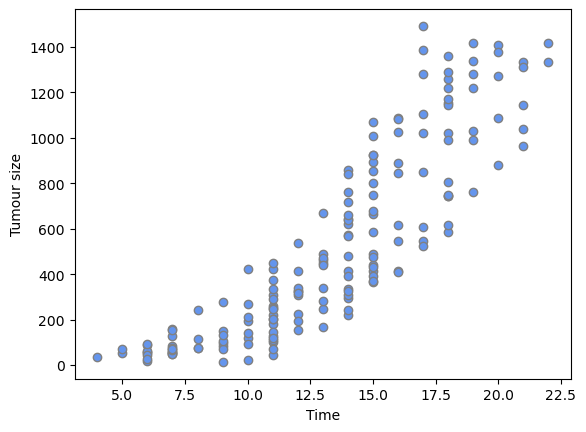

In [4]:
plt.scatter(t, size, color='cornflowerblue', edgecolors='gray')
plt.xlabel('Time')
plt.ylabel('Tumour size')

## Normalisation
Our data is more standardised than the previous example. No need of lo scale here, we are just going to take off the mean and divide by std.

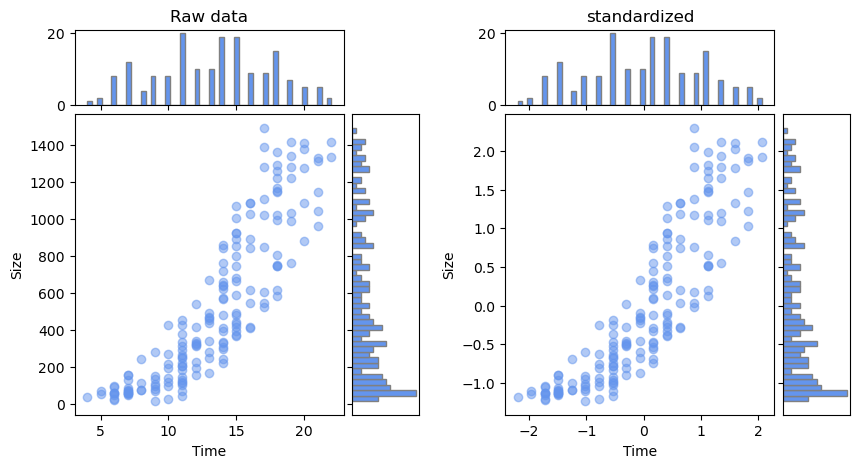

In [5]:
fig = plt.figure(figsize=(10, 5))
outer = gridspec.GridSpec(1, 2, wspace=0.25)

def scatter_with_marginals(gs, x_data, y_data, title):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=gs,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        wspace=0.05,
        hspace=0.05
    )

    ax_scatter = plt.Subplot(fig, inner[1, 0])
    ax_histx = plt.Subplot(fig, inner[0, 0], sharex=ax_scatter)
    ax_histy = plt.Subplot(fig, inner[1, 1], sharey=ax_scatter)

    fig.add_subplot(ax_scatter)
    fig.add_subplot(ax_histx)
    fig.add_subplot(ax_histy)

    # Scatter
    ax_scatter.scatter(x_data, y_data, c='cornflowerblue', alpha=0.5)

    # Marginals
    ax_histx.hist(x_data, bins=50, histtype='step', fill=True, color='cornflowerblue', edgecolor='gray')
    ax_histy.hist(y_data, bins=50, orientation='horizontal', fill=True, color='cornflowerblue', edgecolor='gray')

    # Clean up ticks
    plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    ax_histx.set_title(title)
    ax_scatter.set_xlabel('Time')
    ax_scatter.set_ylabel('Size')
    ax_histy.set_xticks([])

# Plot the orginal data
scatter_with_marginals(outer[0], t, size, "Raw data")

# standardization
norm_t = (t - np.mean(t)) /np.std(t)

norm_size = (size - np.mean(size)) / np.std(size)

scatter_with_marginals(outer[1], norm_t, norm_size, "standardized")

## Data preparation
Here again, we transform our data to torch tensors, train and test splits, and batch them.
We need to add the feature dimension: for now our data is a scalar, but with the neurons we re going to learn features. So if our batch is (64,) (64 scalar), we need to transform it to (64, 1), 1 being the feature (just one dimension for now as the input is scalar. The layers will transforn this to e.g. (64, 32))

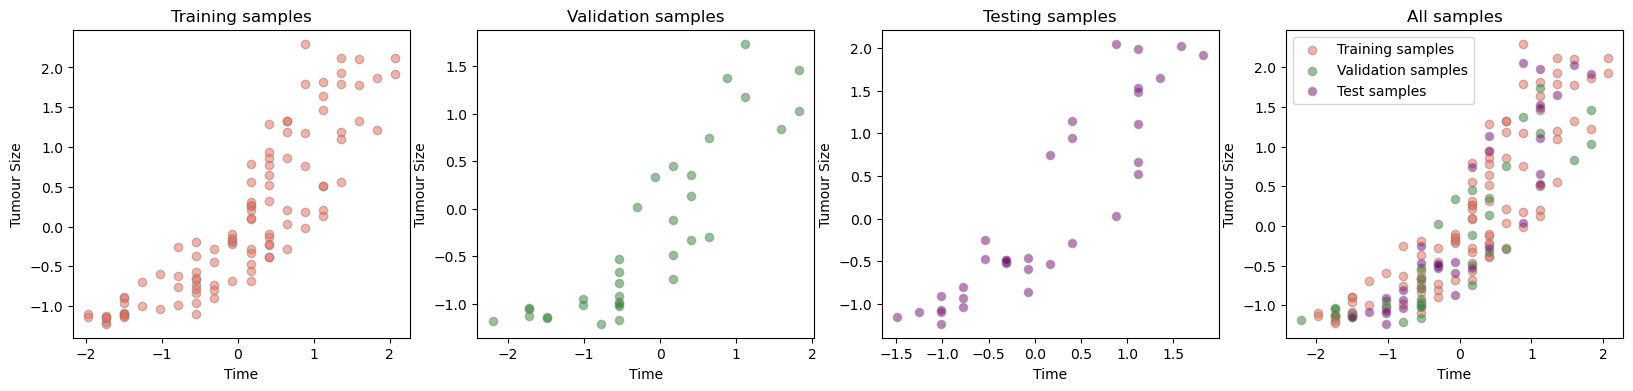

In [6]:

# set the number of samples per group
n_train_samples = int(0.6*len(norm_size))
n_validation_samples = int(0.2*len(norm_size))
n_test_samples = int(0.2*len(norm_size))

# randomise your data for random reprentation in each group
random_samples_ids = np.arange(len(norm_size))
np.random.shuffle(random_samples_ids)

# get the random ids
train_ids = random_samples_ids[:n_train_samples]
validation_ids = random_samples_ids[n_train_samples:n_train_samples+n_validation_samples]
test_ids = random_samples_ids[-n_test_samples:]

# create the sets
x_train = norm_t[train_ids]
y_train = norm_size[train_ids]

x_validation = norm_t[validation_ids]
y_validation = norm_size[validation_ids]

x_test = norm_t[test_ids]
y_test = norm_size[test_ids]

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
plt.subplots_adjust(wspace=0.2)

ax[0].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[1].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[2].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')

ax[3].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[3].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[3].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')
ax[3].legend()

ax[0].set_title('Training samples')
ax[1].set_title('Validation samples')
ax[2].set_title('Testing samples')
ax[3].set_title('All samples')
[axe.set_xlabel('Time') for axe in ax]
[axe.set_ylabel('Tumour Size') for axe in ax];


In [7]:
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()

x_validation = torch.from_numpy(x_validation).float()
y_validation = torch.from_numpy(y_validation).float()

x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test).float()

In [8]:
print(f'train shape: {x_train.shape}')
print(f'validation shape: {x_validation.shape}')
print(f'test shape: {x_test.shape}')

train shape: torch.Size([103, 1])
validation shape: torch.Size([34, 1])
test shape: torch.Size([34, 1])


## Model definition
We are going to use a slightly more complex model. 

We are still using neurons, but we are going to stack them vertically to create a layer: this is done by increasing the secind argument of the Linear function. While it still has one input (time), we create four neurons, which will each create a intermediate output d_i. 

We also add an activation to all our neuron, the ReLU taht we presented in the course. This make the model non linear, even if the neurons themselves are doing a linear operation (still wx + b for each, with a different w each).DS_Store

We then stack a second layer, to create our final output. As we still want one output (tumour size), the final layer as only one neuron, but 4 inputs, the output of the first layer.


In [9]:

class SimpleNonlinearNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 4),   # First hidden layer
            torch.nn.ReLU(),
            torch.nn.Linear(4, 1)    # Output layer
        )
    
    def forward(self, x):
        return self.model(x)

In [10]:
model_simple = SimpleNonlinearNN()
total_params = sum(p.numel() for p in model_simple.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 13


### Optimisation
We still use a MSE loss, with stochastic gradient descent

In [11]:
criterion = torch.nn.MSELoss(size_average = False)
optimizer = torch.optim.SGD(model_simple.parameters(), lr = 0.001)

/opt/homebrew/Caskroom/miniconda/base/envs/DL_intro_VHIO/lib/python3.13/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


# Training
The training model is the exact same as before. Our model is just more complex

In [12]:
batch_size = 64
n_epochs = 50

In [13]:
def train_model(model, batch_size, optimizer):
    losses_steps = []
    losses_epochs = []
    val_losses = []
    for epoch in range(n_epochs):
        loss_epoch = 0

        #shuffle the trainig data each epoch for better stochasticity
        indices = torch.randperm(n_train_samples)
        x_shuffled = x_train[indices]
        y_shuffled = y_train[indices]

        # loop through the dataset per batch
        for i, start_idx in enumerate(range(0, n_train_samples, batch_size)):
            
            # take only the current batch
            end_idx = start_idx + batch_size
            x_batch = x_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            # use the model to predict on the batch
            pred_y = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_y, y_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
        
        pred_val_y = model(x_validation)
        val_loss = criterion(pred_val_y, y_validation)
        val_losses.append(val_loss.detach().numpy())
        # Compute the mean loss on the epoch
        losses_epochs.append(loss_epoch / i)

    return losses_epochs, losses_steps, val_losses


In [14]:
losses_epochs, losses_steps, val_losses = train_model(model_simple, batch_size, optimizer)

<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_46770/1117047694.py:12: SyntaxWarning: invalid escape sequence '\h'
  [axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]


Text(0.5, 1.0, 'Loss per epochs')

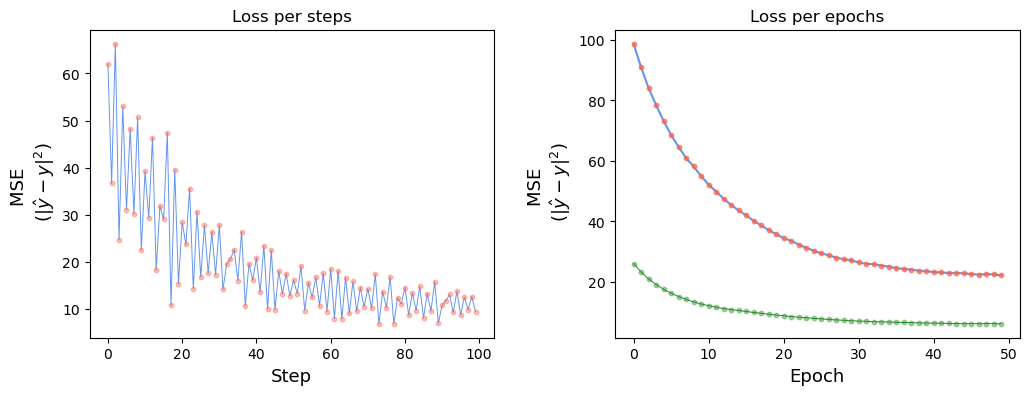

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=0.4, s=10, c='tomato', zorder=5)
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='cornflowerblue', lw=.7)

ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='tomato', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='cornflowerblue')
ax[1].scatter(np.arange(len(losses_epochs)), val_losses, alpha=0.4, s=10, c='forestgreen', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), val_losses, c='forestgreen', lw=.7)


[axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs')

Our model is learning!

# Testing

We can now show what our train mode does, both in the training set and testing set:

In [22]:
pred_on_train = model_simple(x_train)
pred_on_test = model_simple(x_test)

Text(0.5, 1.0, 'On the test set')

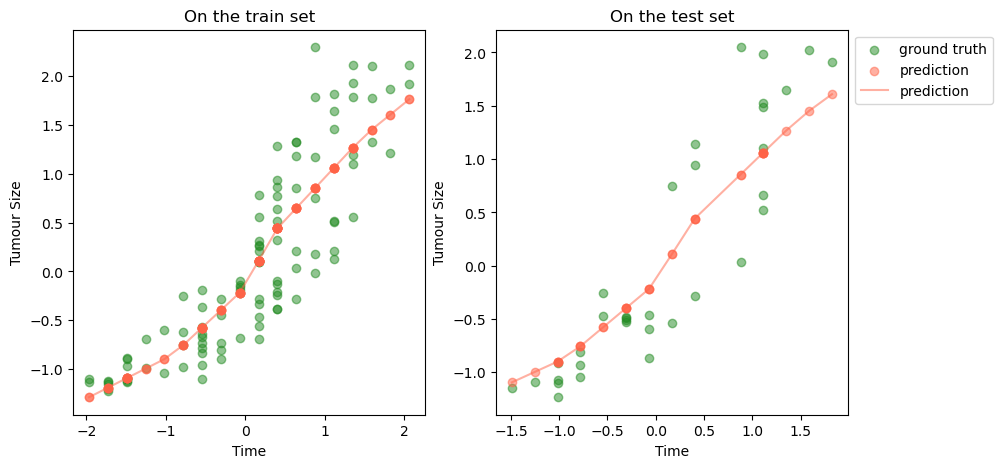

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
train_sort = np.argsort(x_train.detach().numpy()[:, 0])
ax[0].scatter(x_train, y_train, color='forestgreen', alpha=0.5, label='ground truth')
ax[0].scatter(x_train, pred_on_train.detach().numpy(), color='tomato', alpha=0.5, label='prediction')
ax[0].plot(x_train[train_sort], pred_on_train.detach().numpy()[train_sort], color='tomato', alpha=0.5, label='prediction')

test_sort = np.argsort(x_test.detach().numpy()[:, 0])
ax[1].scatter(x_test, y_test, color='forestgreen', alpha=0.5, label='ground truth')
ax[1].scatter(x_test, pred_on_test.detach().numpy(), color='tomato', alpha=0.5, label='prediction')
ax[1].plot(x_test[test_sort], pred_on_test.detach().numpy()[test_sort], color='tomato', alpha=0.5, label='prediction')

ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

[axe.set_xlabel('Time') for axe in ax]
[axe.set_ylabel('Tumour Size') for axe in ax]

ax[0].set_title('On the train set')
ax[1].set_title('On the test set')


We see that we are now non linear!